# EXPLORATORIO

# Comportamiento de Fidelidad III: Exploración de criterios más allá de Chi Cuadrado

Hasta ahora hemos probado dos métricas para medir la **fidelidad** del denoising realizado. Por un lado, se utilizó **RMSE**, una métrica píxel-a-píxel:

$$
RMSE = \sqrt{\frac{1}{N}\sum_{i}(I_i^{den}-I_i^{ref})^2}
$$

El problema con esta métrica es que es sensible a errores grandes y es insensible a estructura espacial. Además, se pudo notar en `EXP-fidelidad_1.ipynb` que con zero-filling y región fija, el RMSE tiende a decrecer monótonamente con over-masking, por lo cual no resulta una buena métrica.

Después, se probó $\Chi^2$:

$$
\Chi^2_\mu = \frac{1}{N_{eff}}\sum_{i}\frac{(I_i^{den} - I_i^{ref})^2}{\sigma_{i}^{2}}
$$

Hasta ahora, se ha podido observar que resulta ser una buena métrica relativa entre mapa ruidoso vs denoiseado, aunque no como test absoluto.

Vamos a ver a continuación si otras métricas de **fidelidad** nos permiten obtener información que hasta ahora no podíamos observar con los test realizados.

# 0. Importaciones y Configuración

In [46]:
from astropy.io import fits #Apertura de archivos .fits
import numpy as np #Manipulación de arrays
import matplotlib.pyplot as plt #Visualización de datos
import os #Manipulación de directorios
import sys #Manipulación de rutas

sys.path.append('../../src') #Añadir ruta de src a sys.path

DATA_DIR = '/Users/kuky/Documents/practica/Denoiser3D-IFU/data/mock_cubes'
IMGS_DIR = '/Users/kuky/Documents/practica/Denoiser3D-IFU/data/imgs'

## 0.1. Parámetros Matplotlib

In [7]:
okabe_ito = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=okabe_ito)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.labelsize": 12,
    "figure.figsize": (3.5, 2.625), # 4:3 ratio for single-column
    "savefig.dpi": 600
})

## 0.2. Definición de Funciones

In [4]:
def cargar_momentos_log(
    subdir, momento_idx, umbral_inicial, umbral_step, cubo, cube_dir,
    umbral_max=None
    ):
    hdu = fits.open(os.path.join(DATA_DIR, cube_dir, f'{cubo}.fits'))
    if umbral_max is None:
        flux_max = np.nanmax(np.squeeze(hdu[0].data))
        cantidad = int(np.floor(np.log(flux_max / umbral_inicial) / np.log(umbral_step))) + 1
    else:
        cantidad = int(np.floor(np.log(umbral_max / umbral_inicial) / np.log(umbral_step))) + 1
    momentos = []
    for k in range(cantidad):
        umbral = umbral_inicial * (umbral_step ** k)
        ruta = os.path.join(
            DATA_DIR, cube_dir, subdir,
            f'iter_flux_{umbral:.3e}',
            f'iter_flux_{umbral:.3e}_moment{momento_idx}.fits',
        )
        hdu = fits.open(ruta)
        momento = np.squeeze(hdu[0].data)
        momentos.append(np.nan_to_num(momento).flatten())
    return momentos

def flux_max(cubo, cube_dir):
    hdu = fits.open(os.path.join(DATA_DIR, cube_dir, f'{cubo}.fits'))
    flux_max = np.nanmax(np.squeeze(hdu[0].data))
    return flux_max

def umbrales_log(flux_max, umbral_inicial, umbral_step):
    cantidad = int(np.floor(np.log(flux_max / umbral_inicial) / np.log(umbral_step))) + 1
    return umbral_inicial * umbral_step ** np.arange(cantidad)

# 1. Contextualización y Debate

Debemos recordar que estamos comparando una **referencia sin ruido (GROUND TRUTH)** con la imagen denoiseada, y queremos saber si el denoising nos acercó más a ella de lo que estaba el mapa ruidoso. Así, notar que estamos hablando de una pregunta de **reducción de error respecto a un objetivo**. Por lo tanto, la formulación correcta debería ser:

$$
\Delta = M (I^{noisy}, I^{ref});vs;M(I^{den}, I^{ref})
$$

Vamos a revisar un par de opciones interesantes considerando este problema.

# 2. Conservación de Flujo (Flux recovery curve vs umbral)

In [5]:
from __future__ import annotations
import numpy as np
from dataclasses import dataclass


# ==================================================================
# Utilidades
# ==================================================================

def _check_shapes(*arrays: np.ndarray) -> None:
    shapes = {a.shape for a in arrays}
    if len(shapes) != 1:
        raise ValueError(f"Shapes incompatibles: {shapes}")


# ==================================================================
# EJE 1 -- FLUX RECOVERY CURVE  (el árbitro científico)
# ==================================================================
# Fundamento: Serra, Jurek & Floer (2012, PASA 29, 296); Serra et al.
# (2015, MNRAS 448, 1922 -- SoFiA). La conservacion de flujo integrado
# como funcion del umbral de mascara penaliza directamente el
# over-smoothing, que las metricas de imagen RECOMPENSAN erroneamente.
#
# Idea: para una rejilla de umbrales (en unidades de sigma del fondo),
# se construye una mascara y se mide que fraccion del flujo verdadero
# (definido por la referencia noiseless) se recupera en cada mapa.

@dataclass
class FluxRecoveryResult:
    thresholds: np.ndarray          # umbrales en unidades de sigma
    eta_map: np.ndarray             # flujo recuperado / flujo verdadero
    total_true_flux: float          # flujo de referencia dentro de su mascara
    sigma_used: float               # sigma del fondo usado para los umbrales


def flux_recovery_curve(
    img: np.ndarray,
    ref: np.ndarray,
    sigma: float,
    thresholds_sigma: np.ndarray | None = None,
    ref_mask: np.ndarray | None = None,
) -> FluxRecoveryResult:
    """
    Curva de recuperacion de flujo de `img` respecto a `ref`.

    Parameters
    ----------
    img : mapa momento-0 a evaluar (ruidoso o denoiseado)
    ref : mapa momento-0 de referencia SIN ruido (ground truth)
    sigma : desviacion estandar del fondo de `img`, medida en una
            region libre de senal (ver noise_sigma_from_negatives o
            medicion directa en region signal-free)
    thresholds_sigma : rejilla de umbrales en unidades de sigma.
                       Default: linspace(0, 8, 40)
    ref_mask : mascara booleana que define la "verdad" (donde hay
               emision real en la referencia). Si None, se usa
               ref > 0 (apropiado para momento-0 noiseless positivo).

    Returns
    -------
    FluxRecoveryResult
    """
    _check_shapes(img, ref)
    if thresholds_sigma is None:
        thresholds_sigma = np.linspace(0.0, 8.0, 40)

    if ref_mask is None:
        ref_mask = ref > 0
    total_true_flux = float(ref[ref_mask].sum())
    if total_true_flux == 0:
        raise ValueError("Flujo verdadero nulo dentro de ref_mask.")

    eta = np.empty_like(thresholds_sigma, dtype=float)
    for k, t in enumerate(thresholds_sigma):
        mask = img > (t * sigma)
        recovered = float(img[mask].sum())
        eta[k] = recovered / total_true_flux

    return FluxRecoveryResult(
        thresholds=np.asarray(thresholds_sigma, dtype=float),
        eta_map=eta,
        total_true_flux=total_true_flux,
        sigma_used=float(sigma),
    )


def compare_flux_recovery(
    noisy: np.ndarray,
    denoised: np.ndarray,
    ref: np.ndarray,
    sigma_noisy: float,
    sigma_denoised: float,
    thresholds_sigma: np.ndarray | None = None,
    ref_mask: np.ndarray | None = None,
) -> dict:
    """
    Compara las curvas de recuperacion de flujo. La interpretacion
    cientifica: a un umbral fijo, el mapa cuya eta esta MAS CERCA de 1
    conserva mejor el flujo verdadero. Una eta que cae bruscamente al
    subir el umbral indica que la senal se perdio (over-smoothing).
    """
    fr_n = flux_recovery_curve(noisy, ref, sigma_noisy, thresholds_sigma, ref_mask)
    fr_d = flux_recovery_curve(denoised, ref, sigma_denoised, thresholds_sigma, ref_mask)
    # np.trapz removido en NumPy 2.0 -> usar trapezoid con fallback
    _trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))
    # error absoluto |eta - 1| integrado sobre umbrales (menor = mejor)
    l1_n = float(_trapz(np.abs(fr_n.eta_map - 1.0), fr_n.thresholds))
    l1_d = float(_trapz(np.abs(fr_d.eta_map - 1.0), fr_d.thresholds))
    return {
        "noisy": fr_n,
        "denoised": fr_d,
        "integrated_dev_noisy": l1_n,
        "integrated_dev_denoised": l1_d,
        "denoising_improves_flux": l1_d < l1_n,
    }

Probemos con el mock_cube `isolated_sub_AC5_N50_width1`.

## 2.1. Apertura Momento-0 Referencia

In [7]:
CUBE_DIR = 'isolated_sub_AC5_N50_width1'

hdu = fits.open(os.path.join(
    DATA_DIR, CUBE_DIR,
    'moments_ref',
    'notnoisy_moment0_AC5.fits'
))

moment_0_ref = np.squeeze(hdu[0].data)

moment_0_ref_flat = np.clip(
    np.nan_to_num(moment_0_ref).flatten(),
    0, None
)

## 2.2. Apertura Momentos-0

In [16]:
IterativeMin = 1.0e-7
IterativeStep = 1.5

cubes_subdir = {
    'noisy': 'isolated_sub_AC5_N50_width1_noisy_sub',
    'soft_5': 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_5',
    'soft_4': 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_4',
    'soft_3': 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_3',
    'soft_2': 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_2',
    'soft_1': 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_1',
}

momentos_0 = {}

for subdir, cube in cubes_subdir.items():
    momento_0 = cargar_momentos_log('moments_noisy', 0, IterativeMin, IterativeStep, cube, CUBE_DIR)
    momentos_0[subdir] = momento_0

umbrales = {}

for subdir, cube in cubes_subdir.items():
    flux_max_val = flux_max(cube, CUBE_DIR)
    umbrales[subdir] = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

Ahora entramos en un problema. La función `flux_recovery_curve` nos pide un $\sigma$, que corresponde al $\sigma$ del fondo del mapa momento-0, medido en una región **dominada por ruido**. El problema con esto es que tras el wavelet denoising el ruido no es blanco ni estacionario - está parcialmente blanqueado de forma espacialmente no uniforme. Esto significa que "el $\sigma$ del mapa denoiseado" no es una cantidad limpia: el MAD que se mida en una región signal-free está inflado por la asimetría que se ha documentado (la señal eleva el umbral wavelet), y de ahí el factor de escala s. Medir $\sigma$ sore el denoiseado es legítimo, pero hay que hacerlo con la corrección s, no como MAD crudo.

De aquí surge la siguiente pregunta: ¿el umbral de la máscara debe basarse en el $\sigma$ del 

# 3. Mapas de Chi-Cuadrado

In [71]:
hdu = fits.open(os.path.join(
    DATA_DIR,
    'isolated_sub_AC5_N50_width1',
    'moments_ref',
    'notnoisy_moment0_AC5.fits'
))
m0_ref = np.squeeze(np.nan_to_num(hdu[0].data))

In [72]:
hdu = fits.open(os.path.join(
    DATA_DIR,
    'isolated_sub_AC5_N50_width1',
    'moments_soft_5',
    'iter_flux_1.946e-05',
    'iter_flux_1.946e-05_moment0.fits'
))
m0_s5 = np.squeeze(np.nan_to_num(hdu[0].data))

In [73]:
hdu = fits.open(os.path.join(
    DATA_DIR,
    'isolated_sub_AC5_N50_width1',
    'moments_soft_7',
    'iter_flux_1.946e-05',
    'iter_flux_1.946e-05_moment0.fits'
))
m0_s7 = np.squeeze(np.nan_to_num(hdu[0].data))

(array([7.480e+03, 2.423e+03, 3.532e+03, 3.008e+03, 1.941e+03, 1.887e+03,
        1.264e+03, 9.760e+02, 1.105e+03, 9.230e+02, 8.430e+02, 7.380e+02,
        6.620e+02, 6.000e+02, 5.000e+02, 5.190e+02, 4.530e+02, 4.470e+02,
        4.090e+02, 3.370e+02, 3.410e+02, 2.930e+02, 3.220e+02, 2.840e+02,
        2.580e+02, 2.630e+02, 2.540e+02, 2.320e+02, 2.260e+02, 2.100e+02,
        2.040e+02, 1.760e+02, 1.910e+02, 1.700e+02, 1.740e+02, 1.660e+02,
        1.730e+02, 1.460e+02, 1.630e+02, 1.490e+02, 1.420e+02, 1.430e+02,
        1.350e+02, 1.300e+02, 1.100e+02, 1.290e+02, 1.140e+02, 1.190e+02,
        1.110e+02, 1.040e+02, 1.040e+02, 9.600e+01, 8.900e+01, 9.000e+01,
        8.200e+01, 9.200e+01, 7.000e+01, 9.300e+01, 7.200e+01, 7.100e+01,
        7.100e+01, 8.200e+01, 6.800e+01, 6.000e+01, 6.600e+01, 6.600e+01,
        6.300e+01, 5.200e+01, 5.900e+01, 5.900e+01, 4.500e+01, 6.200e+01,
        5.100e+01, 5.300e+01, 5.000e+01, 5.000e+01, 5.300e+01, 4.300e+01,
        4.900e+01, 3.700e+01, 4.300e+0

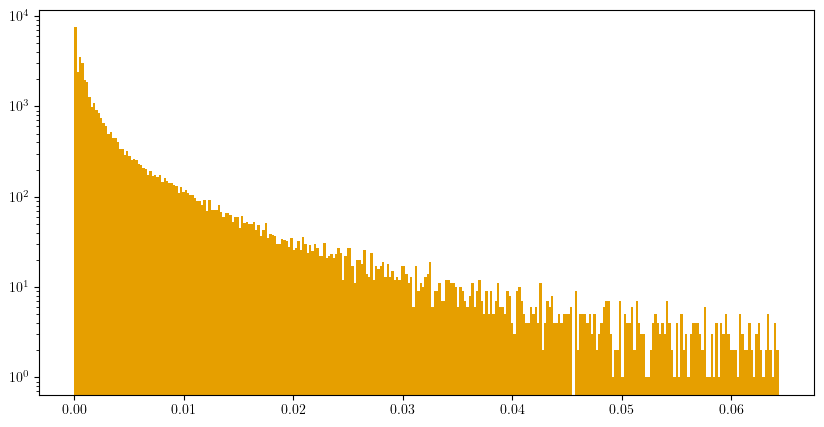

In [95]:
m0_s5_flatten = m0_s5.flatten()
plt.figure(figsize=(10,5))
plt.hist(m0_s5_flatten, bins=300, log=True)

6.4354106e-07
5.6710707e-07


/var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/ipykernel_7623/664585095.py:9: RuntimeWarning: divide by zero encountered in divide
  (m0_s5-m0_ref_s5)/m0_ref_s5,
/var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/ipykernel_7623/664585095.py:9: RuntimeWarning: invalid value encountered in divide
  (m0_s5-m0_ref_s5)/m0_ref_s5,
/var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/ipykernel_7623/664585095.py:21: RuntimeWarning: divide by zero encountered in divide
  (m0_s7-m0_ref_s7)/m0_ref_s7,
/var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/ipykernel_7623/664585095.py:21: RuntimeWarning: invalid value encountered in divide
  (m0_s7-m0_ref_s7)/m0_ref_s7,


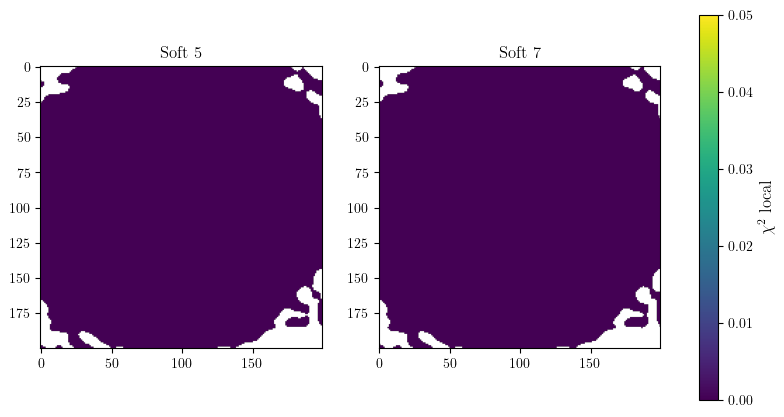

In [96]:
import matplotlib as mpl
fig, axs = plt.subplots(1,2, figsize=(10,5))

min_threshold = np.max(m0_s5) * 0.00001
m0_ref_s5 = m0_ref > min_threshold
print(min_threshold)

im1= axs[0].imshow(
    (m0_s5-m0_ref_s5)/m0_ref_s5,
    #norm=mpl.colors.LogNorm(vmin=10e-8, vmax=10e5)
    vmin=0,
    vmax=0.05
    )

min_threshold = np.max(m0_s7) * 0.00001
m0_ref_s7 = m0_ref > min_threshold
print(min_threshold)

axs[0].set_title('Soft 5')
im2 = axs[1].imshow(
    (m0_s7-m0_ref_s7)/m0_ref_s7,
    vmin=0,
    vmax=0.05
)
axs[1].set_title('Soft 7')
fig.colorbar(mappable=im2, ax=axs, label='$\chi^2$ local')

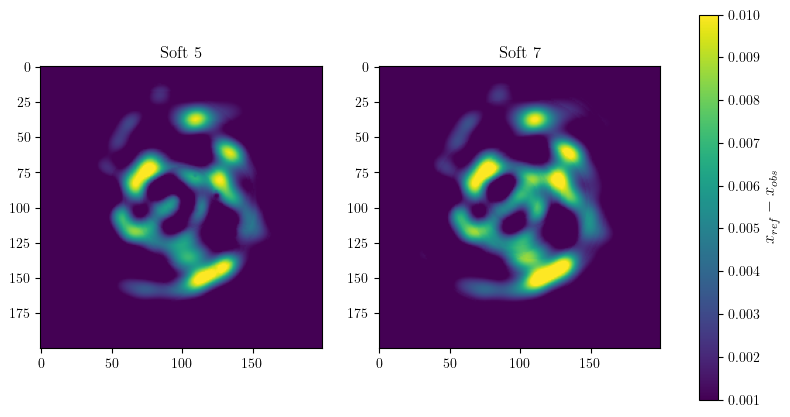

In [70]:
fig, axs = plt.subplots(1,2, figsize=(10,5))

im1 = axs[0].imshow(
    m0_ref-m0_s5,
    #norm=mpl.colors.LogNorm(vmin=10e-8, vmax=10e5)
    vmin=1e-3,
    vmax=1e-2
    )
axs[0].set_title('Soft 5')
im2 = axs[1].imshow(
    m0_ref-m0_s7,
    vmin=1e-3,
    vmax=1e-2
)
axs[1].set_title('Soft 7')
fig.colorbar(mappable=im2, ax=axs, label='$x_{ref} - x_{obs}$')

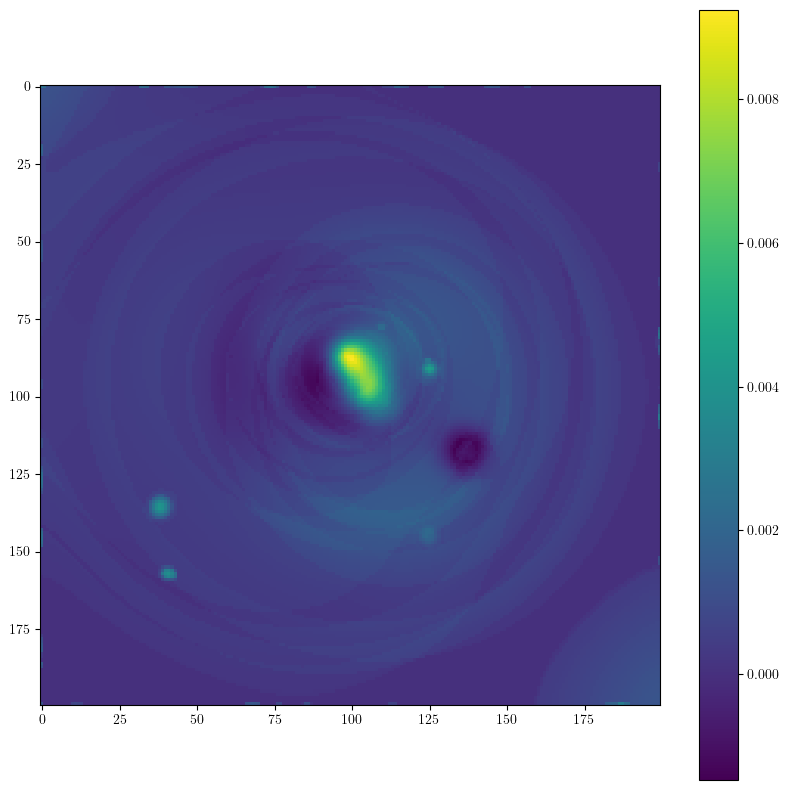

In [67]:
plt.figure(figsize=(10,10))
plt.imshow(
    (m0_ref - m0_s7) - (m0_ref - m0_s5)
)
plt.colorbar()

# 4. Structural Similarity Index (SSIM)

Es una métrica perceptual/estructural. Véase, la idea es capturar simultáneamente la **luminancia, contraste y estructura** local. La idea es detectar si el denoising preserva la morfología de la emisión, no sólo el nivel de flujo.

$$
SSIM(x,y)= \frac{(2\mu_x \mu_y + C_1)(2\sigma_{xy} + C_2)}{(\mu_x^2 + \mu_y^2 + C_1)(\sigma_x^2 + \sigma_y^2 + C_2)}
$$

donde $\mu_x = \frac{1}{N} \sum^{N}_{i=1}x_i$ , $\sigma_x = (\frac{1}{N-1}\sum_{i=1}^{N}(x_i - \mu_x)^2)^{1/2}$ , $\sigma_{xy}=\frac{1}{N-1}\sum^{N}_{i=1}(x_i - \mu_x)(y_i - \mu_y)$. Las constantes son definidas como:

$$
C_1 = (K_1 L)^2
$$

donde $L$ es el rango dinámico de los valores de los píxeles y $K_1$ es una constante positiva muy pequeña. En el paper de *Wang(2004)* se utilizan los valores $K_1=0.01$ y $K_2=0.03$.

Ahora, el tema a solucionar en este caso es el valor de $L$. En *Wang(2003)* se utilizan imágenes de 8 bits, por lo que el valor en ese caso es de 256, distinto a nuestro caso.

$L$ debe derivarse de la imagen de referencia y debe ser el mismo para todas las comparaciones. Vamos a realizar un **rango de referencia** para definir $L$, véase:

$$
L = M_0^{ref} \cdot max() - M_0^{ref} \cdot min()
$$

In [68]:
def cargar_momentos_log(subdir, momento_idx, umbral_inicial, umbral_step, cubo, cube_dir):
    hdu = fits.open(os.path.join(DATA_DIR, cube_dir, f'{cubo}.fits'))
    flux_max = np.nanmax(np.squeeze(hdu[0].data))
    cantidad = int(np.floor(np.log(flux_max / umbral_inicial) / np.log(umbral_step))) + 1
    momentos = []
    for k in range(cantidad):
        umbral = umbral_inicial * (umbral_step ** k)
        ruta = os.path.join(
            DATA_DIR, CUBE_DIR, subdir,
            f'iter_flux_{umbral:.3e}',
            f'iter_flux_{umbral:.3e}_moment{momento_idx}.fits',
        )
        hdu = fits.open(ruta)
        momento = np.squeeze(hdu[0].data)
        momentos.append(np.nan_to_num(momento))
    return momentos

def flux_max(cubo, cube_dir):
    hdu = fits.open(os.path.join(DATA_DIR, cube_dir, f'{cubo}.fits'))
    flux_max = np.nanmax(np.squeeze(hdu[0].data))
    return flux_max

def umbrales_log(flux_max, umbral_inicial, umbral_step):
    cantidad = int(np.floor(np.log(flux_max / umbral_inicial) / np.log(umbral_step))) + 1
    return umbral_inicial * umbral_step ** np.arange(cantidad)

In [69]:
CUBE_DIR = 'isolated_sub_AC5_N50_width1'

AC = 'AC5'

IterativeMin = 1.0e-7
IterativeStep = 1.5

cantidad_de_cubos = 6

In [70]:
moments_ref = {}
for i in range(3):
    hdu = fits.open(os.path.join(
        DATA_DIR,
        CUBE_DIR,
        'moments_ref',
        f'notnoisy_moment{i}_{AC}.fits'
    ))
    moment = np.squeeze(hdu[0].data)
    moment_ref_flat = np.clip(np.nan_to_num(moment),0,None)
    moments_ref[i] = moment_ref_flat

In [71]:
umbrales = {}
for i in range(cantidad_de_cubos):
    if i == 0:
        flux_max_val = flux_max(
            f'{CUBE_DIR}_noisy_sub',
            CUBE_DIR
        )
        umbral = umbrales_log(
            flux_max_val, IterativeMin, IterativeStep
        )
        umbrales['noisy'] = umbral

    else:
        flux_max_val = flux_max(
            f'{CUBE_DIR}_noisy_sub_wavelets_iterative_soft_{i}',
            CUBE_DIR
        )
        umbral = umbrales_log(
            flux_max_val, IterativeMin, IterativeStep
        )
        umbrales[f'soft_{i}'] = umbral

In [72]:
moments = {}
for i in range(cantidad_de_cubos):
    if i == 0:
        moment = cargar_momentos_log(
            'moments_noisy',
            0, IterativeMin, IterativeStep,
            f'{CUBE_DIR}_noisy_sub', CUBE_DIR
        )
        moments['noisy'] = moment
    else:
        moment = cargar_momentos_log(
            f'moments_soft_{i}',
            0, IterativeMin, IterativeStep,
            f'{CUBE_DIR}_noisy_sub_wavelets_iterative_soft_{i}',
            CUBE_DIR
        )
        moments[f'soft_{i}'] = moment


In [73]:
from skimage.metrics import structural_similarity as ssim
L = float(moment_0_ref.max() - moment_0_ref.min())   # rango dinámico de la referencia noiseless

In [74]:
ssim_valores = {}
for i in range(cantidad_de_cubos):
    if i == 0:
        ssim_list = []
        for m in moments['noisy']:

            ssim_value = ssim(
                moments_ref[0], m,
                data_range=L,
                K1=0.01, K2=0.03,
                gaussian_weights=True, sigma=1.5,
                win_size=11
                )

            ssim_list.append(ssim_value)
        ssim_valores['noisy'] = ssim_list
    else:
        ssim_list = []
        for m in moments[f'soft_{i}']:

            ssim_value = ssim(
                moments_ref[0], m,
                data_range=L,
                K1=0.01, K2=0.03,
                gaussian_weights=True, sigma=1.5,
                win_size=11
                )
            
            ssim_list.append(ssim_value)
        ssim_valores[f'soft_{i}'] = ssim_list


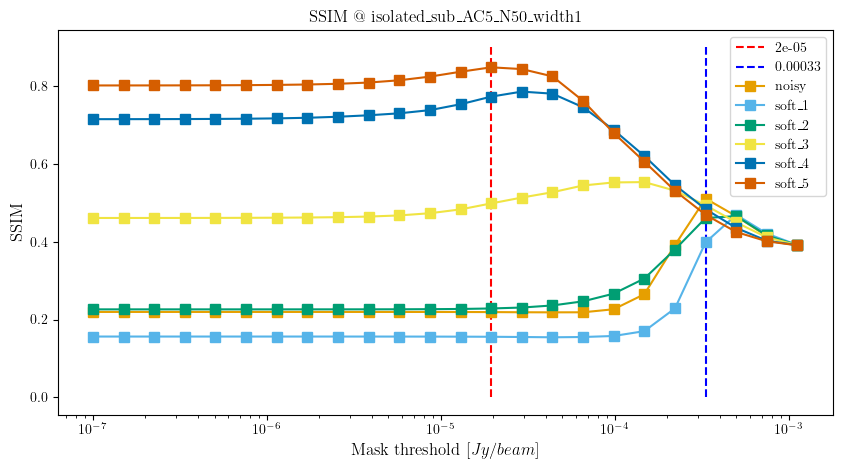

In [100]:
plt.figure(figsize=(10, 5))
for name, ssim_values in ssim_valores.items():
    plt.errorbar(
        umbrales[name],
        ssim_values,
        ms=7,
        label=f'{name}',
        marker='s'
    )
plt.xlabel('Mask threshold [$Jy/beam$]')
plt.ylabel('SSIM')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
plt.xscale('log')
plt.vlines(umbrales['soft_5'][13], 0, 0.9, colors='red', linestyles='--', label=umbrales['soft_5'][13].round(5))
plt.vlines(umbrales['noisy'][20], 0, 0.9, colors='blue', linestyles='--', label=umbrales['noisy'][20].round(5))
plt.title(f'SSIM @ {CUBE_DIR}')
plt.legend()
plt.savefig(os.path.join(IMGS_DIR, f'ssim_{CUBE_DIR}.png'))

In [101]:
score, ssim_map_noisy_best = ssim(moments_ref[0], moments['noisy'][20], data_range=L, K1=0.01, K2=0.03,gaussian_weights=True, sigma=1.5, win_size=11, full=True)
score, ssim_map_soft_5_best = ssim(moments_ref[0], moments['soft_5'][13], data_range=L, K1=0.01, K2=0.03,gaussian_weights=True, sigma=1.5, win_size=11, full=True)

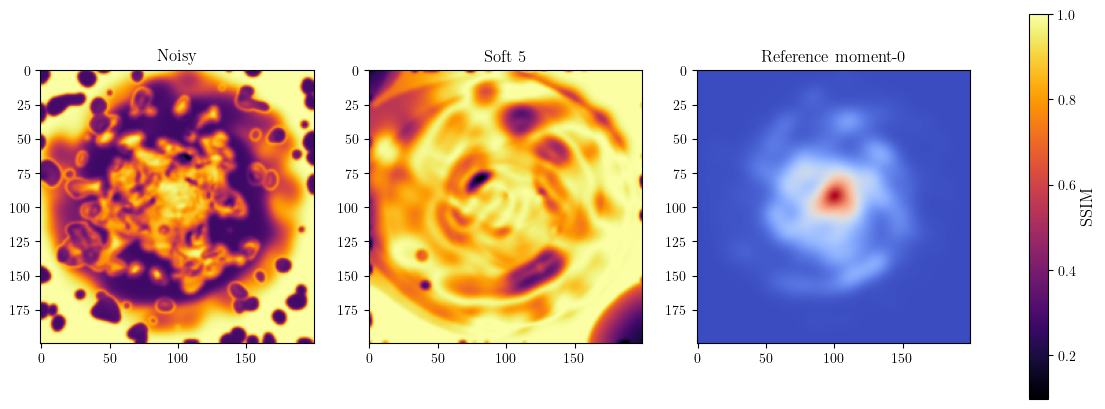

In [111]:
fig, axs = plt.subplots(1,3, figsize=(15,5))

im1 = axs[0].imshow(ssim_map_noisy_best, cmap='inferno')
axs[0].set_title('Noisy')
im2 = axs[1].imshow(ssim_map_soft_5_best, cmap='inferno')
axs[1].set_title('Soft 5')
im3 = axs[2].imshow(moments_ref[0], cmap='coolwarm')
axs[2].set_title('Reference moment-0')
fig.colorbar(mappable=im2, ax=axs, label='SSIM')

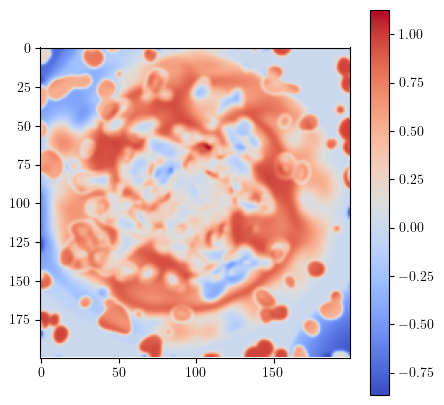

In [109]:
plt.figure(figsize=(5,5))
plt.imshow(ssim_map_soft_5_best-ssim_map_noisy_best, cmap='coolwarm')
plt.colorbar()